# JURNAL PCD MODUL II : Ekualisasi dan Spesifikasi Histogram
Raissa Bunga Astrella - F1D02410087

In [74]:
import numpy  as np
import matplotlib.pyplot as plt
import cv2 as cv2

# liblary
mendeklarasikan library, dalam kodeini liblary cv2 digunakan untuk mengubah ke grayscale dan membaca citra. Liblary numpy digunakan untuk operasi matematika dan array. Liblary matplotlib.pyplot untuk menampilkan gambar dan grafik histogram

Kode dibawah ini digunakan untuk membaca citra yang akan di proses, serta kode untuk merubah citra ke grayscale ataupun ke RGB. Serta terdapat kode yang digunakan untuk menampilkan gambar

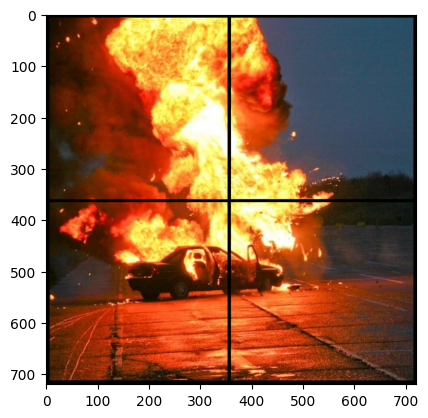

In [75]:
bom = cv2.imread("Assets/Meledak.png")
bom = cv2.cvtColor(bom, cv2.COLOR_BGR2RGB)
windut = cv2.imread("Assets/Windut.png")
windut = cv2.cvtColor(windut, cv2.COLOR_BGR2RGB)
bureng = cv2.imread("Assets/Bunga.png")
bureng = cv2.cvtColor(bureng, cv2.COLOR_BGR2RGB)
sky = cv2.imread("Assets/Langit.png")
sky = cv2.cvtColor(sky, cv2.COLOR_RGB2GRAY)
plt.imshow(bom,cmap='gray')

Kode dibawah ini digunakan untuk memotong citra sesuai dengan sumbu y, sumbu x. Serta Kode untuk menampilkan gambar

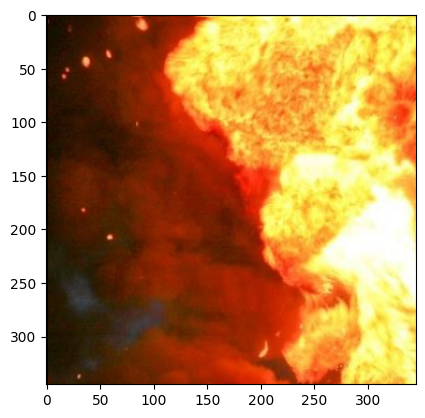

In [6]:
potong1 = bom [5:350 , 5:350]
plt.imshow(potong1, cmap='gray')

Kode dibawah ini digunakan untuk memotong citra sesuai dengan sumbu y, sumbu x. Serta Kode untuk menampilkan gambar

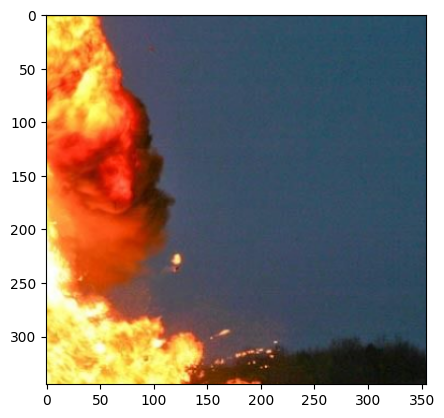

In [7]:
potong2 = bom [5:350 , 360:715]
plt.imshow(potong2, cmap='gray')

Kode dibawah ini digunakan untuk memotong citra sesuai dengan sumbu y, sumbu x. Serta Kode untuk menampilkan gambar

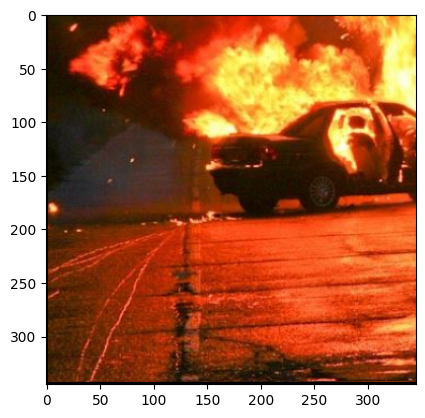

In [8]:
potong3 = bom [370:715 , 5:350]
plt.imshow(potong3, cmap='gray')

Kode dibawah ini digunakan untuk memotong citra sesuai dengan sumbu y, sumbu x. Serta Kode untuk menampilkan gambar

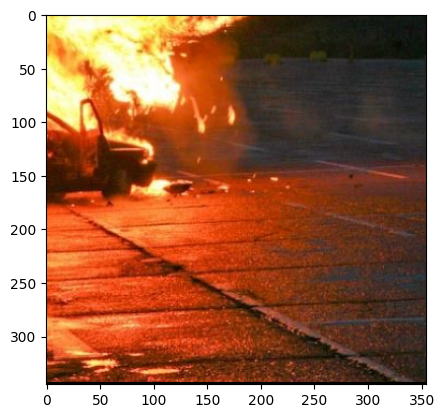

In [9]:
potong4 = bom [370:715 ,360:715]
plt.imshow(potong4, cmap='gray')

Kode di awah ini digunaka untuk menampilkan gambar sekaligus dengan posisi yang di atur sesuai koordinat matrix

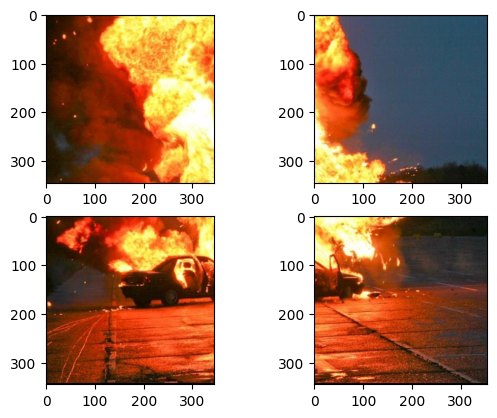

In [10]:
plt.subplot(2,2,1)
plt.imshow(potong1, cmap='gray')
plt.subplot(2,2,2)
plt.imshow(potong2, cmap='gray')
plt.subplot(2,2,3)
plt.imshow(potong3, cmap='gray')
plt.subplot(2,2,4)
plt.imshow(potong4, cmap='gray')

In [11]:
def merge_image(image1, image2, orientation='H'):

    # Horizontal merge
    if orientation == 'H':

        height = max(image1.shape[0], image2.shape[0])
        total_width = image1.shape[1] + image2.shape[1]

        # Grayscale image
        if len(image1.shape) == 2:
            merged = np.zeros((height, total_width), dtype=image1.dtype)

        # Color image
        else:
            merged = np.zeros(
                (height, total_width, image1.shape[2]),
                dtype=image1.dtype
            )

        # Place first image
        merged[0:image1.shape[0], 0:image1.shape[1]] = image1

        # Place second image
        merged[
            0:image2.shape[0],
            image1.shape[1]:image1.shape[1] + image2.shape[1]
        ] = image2

    # Vertical merge
    else:

        total_height = image1.shape[0] + image2.shape[0]
        width = max(image1.shape[1], image2.shape[1])

        # Grayscale image
        if len(image1.shape) == 2:
            merged = np.zeros((total_height, width), dtype=image1.dtype)

        # Color image
        else:
            merged = np.zeros(
                (total_height, width, image1.shape[2]),
                dtype=image1.dtype
            )

        # Place first image
        merged[0:image1.shape[0], 0:image1.shape[1]] = image1

        # Place second image
        merged[
            image1.shape[0]:image1.shape[0] + image2.shape[0],
            0:image2.shape[1]
        ] = image2

    return merged

# Fungsi Merge
Fungsi diatas yakni merge_image digunakkan untuk menggabungkan dua gambar (image1 dan image2) secara horizontal ('H') atau vertikal ('V') berdasarkan parameter. Saat menggabungkan secara horizontal kanvas kosong dibuat dengan lebar total kedua gambar dan tingginya mengikitu gambar paling tinggi, setelah itu masing-masing ditempatkan dari kiri ke kanan berdampingan. Jika digabungkan secara vertikal kanvas dibuat dengan tinggi total kedua gambar lalu lebarnya mengikuti yang paling lebar, setelah itu gambar ditumpuk dari atas ke bawah

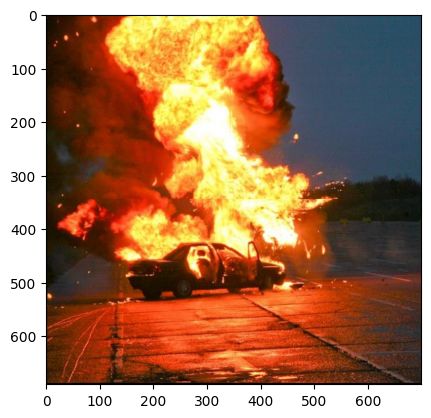

In [12]:
gabung1 = merge_image(potong1, potong2, 'H')
gabung2 = merge_image(potong3, potong4, 'H')
gabungan = merge_image(gabung1, gabung2, 'V')

plt.imshow(gabungan, cmap="gray")


Fungsi di atas digunakan untuk memanggil fungsi merge, dan disimpan dalam variabel baru yakni gabung 1,2 dan gabungan

(690, 700)

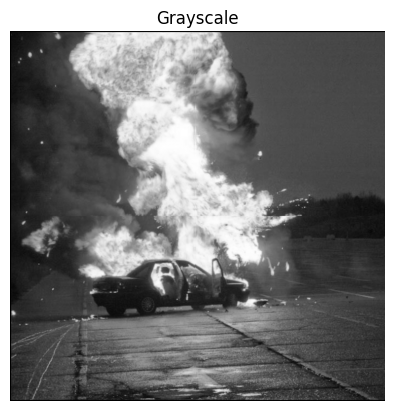

In [13]:
abu = np.zeros((gabungan.shape[0], gabungan.shape[1]),dtype=np.uint8)
for i in range(gabungan.shape[0]):
    for j in range(gabungan.shape[1]):
        r, g, b = gabungan[i, j]
        abu[i, j] = int(0.299*r + 0.587*g + 0.114*b)

plt.imshow(abu, cmap='gray')
plt.title("Grayscale")
plt.axis('off')
abu.shape

# Grayscale manual
Kode di atas digunakan untuk merubah gambar menjadi graysclae. Array abu dibuat kosong berukuran sama dengangabungan tapi hanya dua dimensi, gak ada channel warnanya. Lalu piksel-pikselnya di telusuri lewat nested loop buat diambil nilai R, G dan B setelah itu dihitung dengan nilai yang sudah tertera di kode. 

# Fungsi Ekualisasi
Fungsi ekualisasi buat ningkatin kontras gambar secara manual, jadi gambar yang tadinya kegelapan atau keterangan bisa jadi lebih jelas detailnya. Pertama bikin histogram dulu buat ngitung ada berapa piksel untuk tiap nilai kecerahan dari 0 sampai 255. Habis itu hitung CDF nya, yaitu akumulasi nilai histogram yang dijumlahin terus dari kiri ke kanan. Terus nilai CDF itu dinormalisasi pake rumus CDF × 255 / (tinggi × lebar) supaya nilainya balik lagi ke rentang 0–255. Terakhir, setiap piksel di gambar diganti nilainya pake hasil normalisasi tadi. Jadi outputnya itu gambar baru yang distribusi kecerahannya lebih merata.

In [14]:
def ekualisasi(citra):

    height, width = citra.shape

    # Histogram
    hist = np.zeros(256, dtype=int)

    # Hitung histogram citra
    for i in range(height):
        for j in range(width):

            pixel = citra[i, j]
            hist[pixel] += 1

    # CDF
    cdf = np.zeros(256, dtype=int)

    cdf[0] = hist[0]

    # Hitung CDF
    for i in range(1, 256):

        cdf[i] = cdf[i - 1] + hist[i]

    # Normalisasi CDF
    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8)

    # Hasil ekualisasi
    hasil = np.zeros_like(citra, dtype=np.uint8)

    # Terapkan hasil CDF normalisasi
    for i in range(height):
        for j in range(width):

            pixel = citra[i, j]
            hasil[i, j] = cdf_normal[pixel]

    return hasil

Text(0.5, 1.0, 'Ekualisasi')

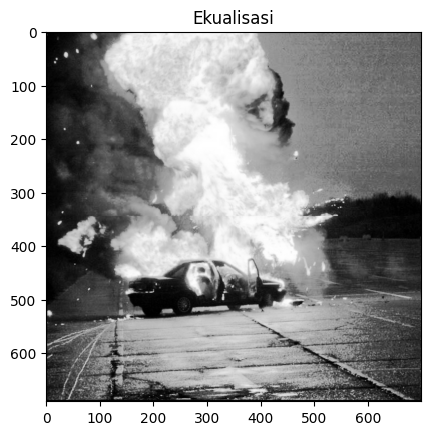

In [15]:
equal=ekualisasi(abu)
plt.imshow(equal, cmap='gray')
plt.title("Ekualisasi")

Kode di atas digunakan untuk menerapkan fungsi ekualisasi ke gambar

# Fungsi Membuat Histogram
Fungsi histo tugasnya buat ngitung frekuensi tiap nilai piksel (0–255) dari gambar secara manual pake nested loop, Terus hasilnya itu berupa list 256 elemen. Lalu plot_histo digunakan untuk nampilin histogram satu gambar dalam bentuk bar chart, bisa dikustomisasi judulnya dan warna batangnya sesuai parameter yang taruh. plot_histo_gabungan nampilin dua histogram sekaligus dalam satu grafik dengan warna hijau dan merah yang semi-transparan (alpha=0.5), tujuannya biar kita bisa langsung bandingin distribusi piksel sebelum dan sesudah ekualisasi secara visual. 

In [71]:
def histo(image):
    histogram = [0] * 256

    height = len(image)
    width = len(image[0]) if height > 0 else 0

    for i in range(height):
        for j in range(width):
            val = int(image[i][j])
            histogram[val] += 1

    return histogram


def plot_histo(histogram, title, ImgColor):
    plt.figure(figsize=(10, 5))

    plt.xlabel("Pixel Intensity")
    plt.ylabel("Number of Pixels")
    plt.title(title)

    plt.bar(range(256), histogram, color=ImgColor, width=0.8)

    plt.show()

def plot_histo_gabungan(hist1, hist2):
    plt.figure(figsize=(10, 5))

    plt.bar(
        range(256),
        hist1,
        color="green",
        alpha=0.5,
        label="Histogram Sebelum Ekualisasi"
    )

    plt.bar(
        range(256),
        hist2,
        color="red",
        alpha=0.5,
        label="Histogram Sesudah Ekualisasi"
    )

    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Jumlah Piksel")
    plt.title("Gabungan Histogram Gambar ke-1 dan Gambar ke-2")
    plt.legend()

    plt.show()

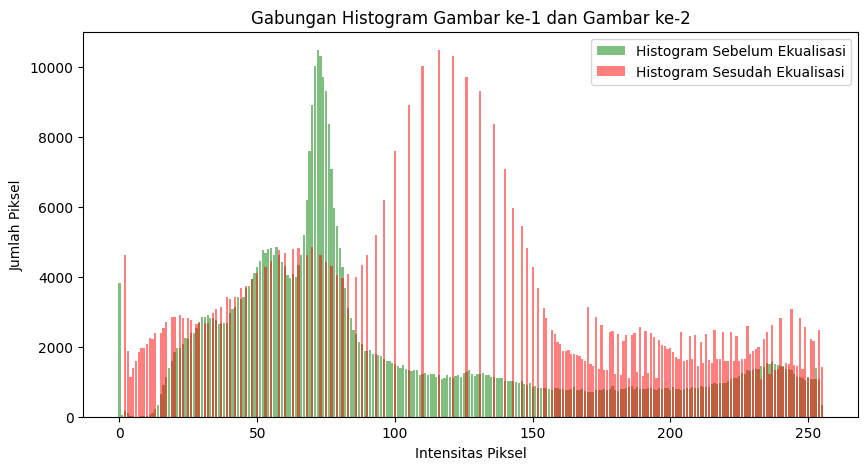

In [73]:
histowal = histo(abu)
histoeq  = histo(equal)
plot_histo_gabungan(histowal, histoeq)

Kode di atas digunakan untuk menerapkan fungsi histo

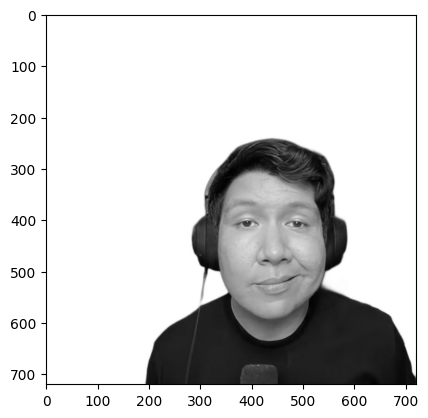

In [18]:
winbu = np.zeros((windut.shape[0], windut.shape[1]),dtype=np.uint8)
for i in range(windut.shape[0]):
    for j in range(windut.shape[1]):
        r, g, b = windut[i, j]
        winbu[i, j] = int(0.299*r + 0.587*g + 0.114*b)
plt.imshow(winbu, cmap="gray")

Fungsi di atas digunakan untuk mengubah citra ke grayscale secara manual

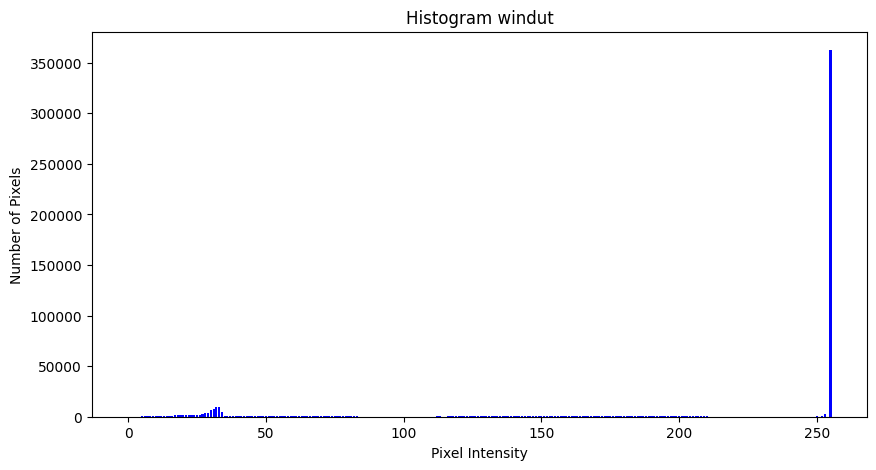

In [19]:
winto = histo(winbu)
plot_histo(winto, "Histogram windut", "blue")

Fungsi di atas digunaka untuk menampilkan dan membaca histogram 

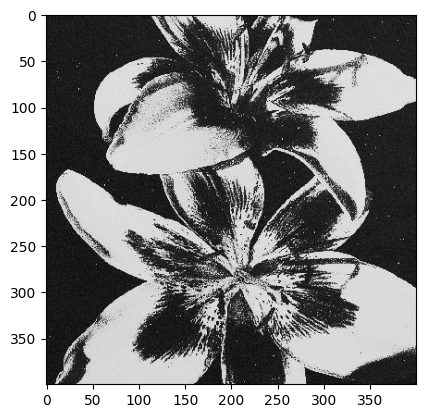

In [20]:
bubu = np.zeros((bureng.shape[0], bureng.shape[1]),dtype=np.uint8)
for i in range(bureng.shape[0]):
    for j in range(bureng.shape[1]):
        r, g, b = bureng[i, j]
        bubu[i, j] = int(0.299*r + 0.587*g + 0.114*b)
plt.imshow(bubu, cmap="gray")

Fungsi di atas digunakan untuk mengubah citra ke grayscale secara manual

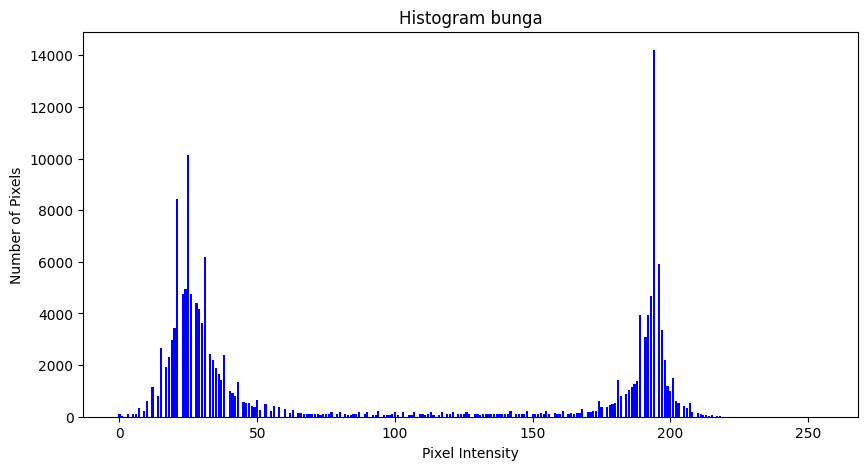

In [21]:
buto = histo(bubu)
plot_histo(buto, "Histogram bunga", "blue")

Fungsi di atas digunakan untuk menerapkan dan menapilkan histogram dari gambar bunga abu

# Fungsi spesifikasi
Fungsi spec dibawah ini digunakan buat seolah-olah kita maksa distribusi kecerahan gambar sumber biar mirip sama distribusi gambar target Pertama kedua gambar dikonversi ke grayscale dulu kalau masih berwarna. Terus histogram masing-masing gambar dihitung secara manual, lalu CDF-nya dihitung dan dinormalisasi ke rentang 0–1 (bukan 0–255 kayak ekualisasi biasa) supaya bisa dibandingkan secara proporsional meski ukuran kedua gambar beda. Untuk tiap nilai intensitas di source (0–255), dicari nilai intensitas di target yang CDF-nya paling dekat, lalu hubungan itu disimpan di map_hist sebagai tabel pemetaan. Terakhir, setiap piksel di gambar source ditukar nilainya sesuai tabel tadi. 

In [29]:
def spec(source_image, target_image):
    if len(source_image.shape) == 3:
        source_image = cv2.cvtColor(source_image.astype(np.uint8), cv2.COLOR_BGR2GRAY)
    if len(target_image.shape) == 3:
        target_image = cv2.cvtColor(target_image.astype(np.uint8), cv2.COLOR_BGR2GRAY)

    hist_source = np.zeros(256, dtype=int)
    hist_target = np.zeros(256, dtype=int)

    # Compute histogram of source image
    for i in range(source_image.shape[0]):
        for j in range(source_image.shape[1]):
            pixel_value = source_image[i, j]
            hist_source[pixel_value] += 1

    # Compute histogram of target image
    for i in range(target_image.shape[0]):
        for j in range(target_image.shape[1]):
            pixel_value = target_image[i, j]
            hist_target[pixel_value] += 1

    cdf_source = np.zeros(256, dtype=float)
    cdf_target = np.zeros(256, dtype=float)

    cdf_source[0] = hist_source[0]
    cdf_target[0] = hist_target[0]

    # Compute CDF
    for i in range(1, 256):
        cdf_source[i] = cdf_source[i - 1] + hist_source[i]
        cdf_target[i] = cdf_target[i - 1] + hist_target[i]

    # Normalize CDF
    cdf_source = cdf_source / cdf_source[-1]
    cdf_target = cdf_target / cdf_target[-1]

    map_hist = np.zeros(256, dtype=np.uint8)

    # Histogram mapping
    for i in range(256):

        diff = np.abs(cdf_target - cdf_source[i])

        # Find index with smallest difference
        j = np.argmin(diff)

        map_hist[i] = j

    height, width = source_image.shape

    result = np.zeros((height, width), dtype=np.uint8)

    # Apply mapping to source image
    for i in range(height):
        for j in range(width):
            result[i, j] = map_hist[source_image[i, j]]

    return result

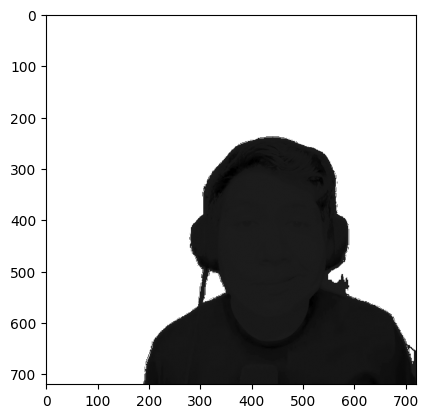

In [30]:
spec1 = spec(winbu, bubu)
plt.imshow(spec1, cmap = "gray")

Fungsi di atas digunakan untuk mengubah citra ke grayscale secara manual

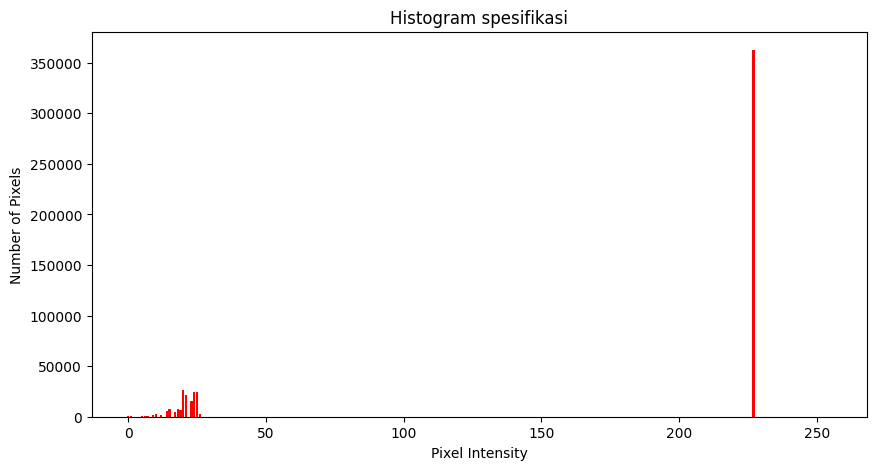

In [76]:
winbuto = histo(spec1)
plot_histo(winbuto, "Histogram spesifikasi", "red")

Fungsi di atas digunakan untuk menerapkan dan menapilkan histogram dari gambar winbuto

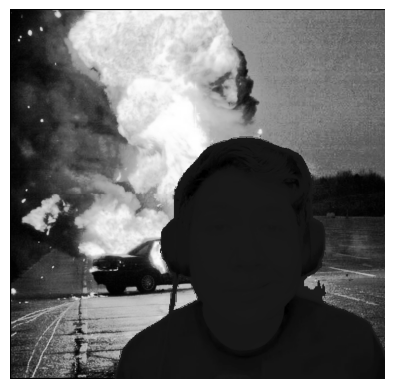

In [32]:
min_h_21 = min(equal.shape[0], spec1.shape[0])
min_w_21 = min(equal.shape[1], spec1.shape[1])

equal_crop = equal[:min_h_21, :min_w_21]
spec1_crop = spec1[:min_h_21, :min_w_21]

result = np.zeros((min_h_21, min_w_21, 3), dtype=np.uint8)

for i in range(spec1_crop.shape[0]):
    for j in range(spec1_crop.shape[1]):
        if spec1_crop[i, j] > 200:
            result[i, j] = equal_crop[i, j]
        else:
            result[i, j] = spec1_crop[i, j]

plt.imshow(result, cmap="gray")
plt.axis("off")
plt.show()

# Fungsi Timpa
Kode diatas nggabungin dua gambar(`equal` dan `spec1`) berdasarkan kondisi nilai piksel. Pertama, kedua gambar di-crop dulu ke ukuran yang sama (ambil dimensi terkecil dari keduanya) biar bisa diproses piksel per piksel tanpa error. Terus dibuat kanvas kosong result berukuran sama tapi 3 channel (RGB). Nah di bagian nested loop-nya, ada logika sederhana kalau nilai piksel spec1 lebih dari 200** (artinya area yang sangat terang/putih), maka piksel yang dipakai diambil dari `equal`, kalau tidak, tetap pakai piksel dari spec1. Efeknya seperti masking — area terang di `spec1` digantiin sama gambar `equal`, sementara area gelapnya tetap dari `spec1` sendiri. Menariknya, `result` dibuat 3 channel padahal kedua input grayscale, jadi hasilnya bakal tampil sebagai gambar grayscale yang dibungkus format RGB.

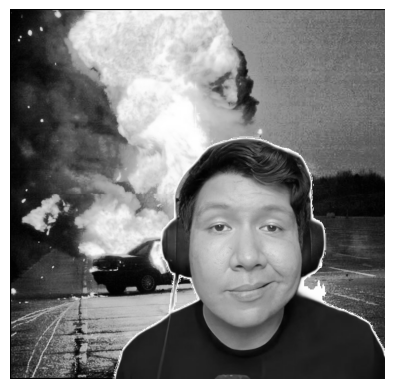

(690, 700, 3)

In [33]:
min_h_22 = min(result.shape[0], winbu.shape[0])
min_w_22 = min(result.shape[1], winbu.shape[1])

bg2 = result[:min_h_22, :min_w_22]
winbu_crop = winbu[:min_h_22, :min_w_22]

result2 = np.zeros((min_h_21, min_w_21, 3), dtype=np.uint8)

for i in range(min_h_22):
    for j in range(min_w_22):
        if winbu_crop[i, j] > 254:
            result2[i, j] = bg2[i, j]
        else:
            result2[i, j] = winbu_crop[i, j]

plt.imshow(result2, cmap="gray")
plt.axis("off")
plt.show()
result2.shape

# Fungsi Timpa
Menggabungkan `result` sama `winbu`. Kedua gambar di-crop ke ukuran terkecil dulu, terus diproses piksel per piksel dengan logika kalau piksel `winbu` nilainya lebih dari 254**, maka ambil piksel dari `result` sebagai background, kalau tidak, tetap pakai piksel dari `winbu`. Bedanya sama kode sebelumnya ada di threshold-nya yang jauh lebih ketat kalau sebelumnya 200, sekarang 254 artinya yang disingkirin dari `winbu` cuma piksel yang beneran putih sempurna, jadi masking-nya lebih presisi. 

(490, 735)

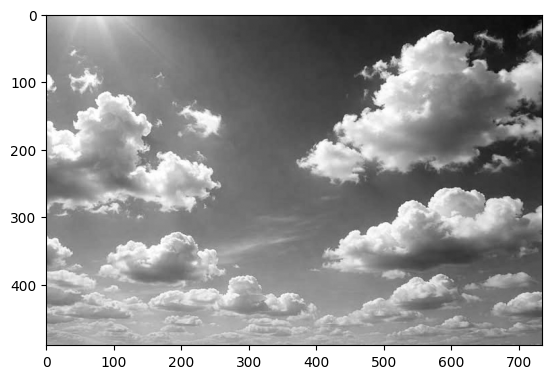

In [36]:
plt.imshow(sky, cmap="gray")
sky.shape

Kode di atas digunakan untuk memanggil fungsi grayscale

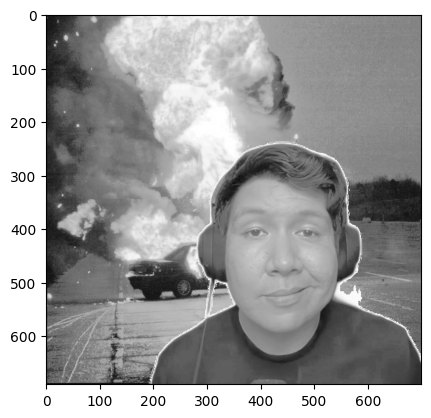

In [38]:
spec2 = spec(result2, sky)
plt.imshow(spec2, cmap = "gray")

Kode di atas digunakan untuk memanggil fungsi grayscale

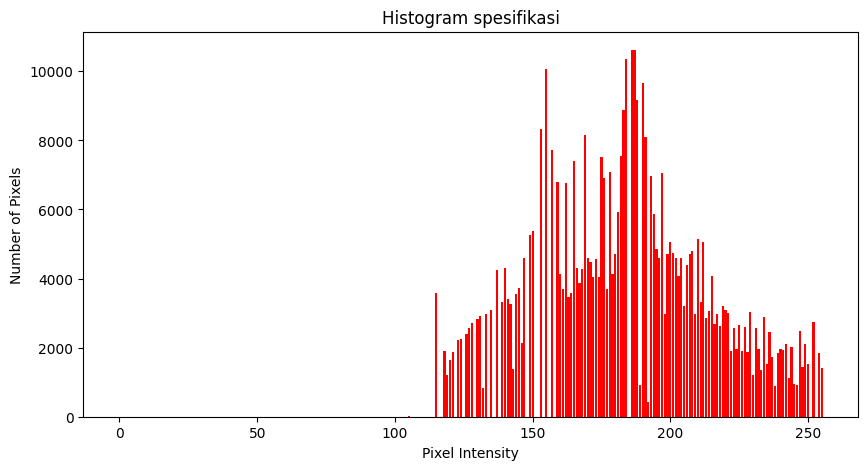

In [39]:
histospec2 = histo(spec2)
plot_histo(histospec2, "Histogram spesifikasi", "red")

# Analisis Histogram

Histogram ini nunjukkin bahwa distribusi piksel hasil histogram specification semuanya numpuk di rentang intensitas 110–255, jadi gambar nggak punya area gelap sama sekali dan cenderung terang semua. Puncaknya ada di sekitar intensitas 155 dan 185–190 dengan ~10.000 piksel, dan polanya cukup tajam-tajam alias naik-turun nggak merata. Mapping CDF emang sering bikin beberapa nilai intensitas jadi numpuk di titik tertentu. Gambar source udah berhasil disesuaikan tone-nya ngikutin karakter gambar target yang memang terang.

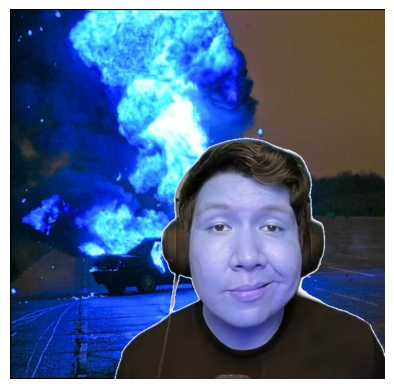

In [69]:
windutbalik = cv2.imread("Assets/Windut.png")
windutres = np.zeros_like(windutbalik)

for i in range(windutbalik.shape[0]):
    for j in range(windutbalik.shape[1]):

        # winbu = grayscale
        if winbu[i, j] < 250:
            windutres[i, j] = windutbalik[i, j]

min_h = min(gabungan.shape[0], windutres.shape[0])
min_w = min(gabungan.shape[1], windutres.shape[1])

meletup = gabungan[:min_h, :min_w]
windutres = windutres[:min_h, :min_w]

meletup = cv2.cvtColor(gabungan, cv2.COLOR_RGB2BGR)
windut_last = np.zeros_like(windutres)

for i in range(windutres.shape[0]):
    for j in range(windutres.shape[1]):

        if (windutres[i, j, 0] == 0 and
            windutres[i, j, 1] == 0 and
            windutres[i, j, 2] == 0):

            windut_last[i, j] = meletup[i, j]
        else:
            windut_last[i, j] = windutres[i, j]

plt.imshow(windut_last)
plt.axis("off")
plt.show()

Kode ini tujuan akhirnya nempel objek `windut` ke atas gambar `gabungan` dengan cara ngilangin background-nya dulu. Prosesnya dua tahap pertama, gambar `windut` di-filter pake mask dari `winbu` (versi grayscale-nya), piksel yang nilainya di bawah 250 dipertahankan, sisanya dibiarkan hitam (0,0,0), efeknya background putih `windut` jadi ilang dan tinggal objeknya aja. Kedua, hasil filter tadi digabung sama `gabungan`kalau pikselnya hitam (artinya bekas background yang dihapus), tampilin piksel dari `gabungan` sebagai background, kalau bukan hitam, tampilin piksel `windut`-nya. Hasilnya objek `windut` keliatan "berdiri" di atas gambar `gabungan` — mirip banget sama teknik chroma key / green screen tapi pake deteksi warna putih dan hitam secara manual.